# ハンズオン3: 可視化によるモデルデバッグ

**— 「目的関数値が良い ≠ 解が正しい」を体感しよう —**

## 概要

最適化モデルを構築して求解すると、ソルバーは目的関数値を最小化した「最適解」を返します。
しかし、**制約が不足していると、数値上は良い解でも現実には使えない解** になることがあります。

このハンズオンでは、倉庫レイアウト問題（QAP）を題材に、
**可視化がモデルデバッグに不可欠** であることを体験します。

### 5つのステップ

1. **データ準備** — 倉庫データ（商品・頻度・棚・距離）を定義
2. **不完全なモデルで求解** — 制約を1つ省略したモデルで解く
3. **可視化で異常発見** — 棚の配置図を描いて問題を発見
4. **制約を追加して再求解** — 正しいモデルで解き直す
5. **比較** — 不完全 vs 完全モデルを並べて教訓を確認

---
## Step 1: データ準備

ハンズオン2と同じ倉庫データを使います。

In [1]:
import jijmodeling as jm
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"JijModeling version: {jm.__version__}")

JijModeling version: 2.2.0


In [2]:
# 商品リスト（10種類）
product_names = [
    "ビール", "おつまみ", "お米", "調味料", "冷凍食品",
    "洗剤", "シャンプー", "トイレットペーパー", "お菓子", "飲料水",
]
N = len(product_names)

# 可視化用の英語ラベル
product_labels = [
    "Beer", "Snacks", "Rice", "Seasoning", "Frozen",
    "Detergent", "Shampoo", "Toilet Paper", "Sweets", "Water",
]

# 同時注文頻度（回/月）
freq_data = np.full((N, N), 5.0)
np.fill_diagonal(freq_data, 0)

high_freq_pairs = [
    (0, 1, 85),   # ビール - おつまみ
    (0, 9, 40),   # ビール - 飲料水
    (1, 8, 55),   # おつまみ - お菓子
    (2, 3, 70),   # お米 - 調味料
    (2, 4, 30),   # お米 - 冷凍食品
    (3, 4, 45),   # 調味料 - 冷凍食品
    (5, 6, 90),   # 洗剤 - シャンプー
    (5, 7, 60),   # 洗剤 - トイレットペーパー
    (6, 7, 50),   # シャンプー - トイレットペーパー
    (8, 9, 65),   # お菓子 - 飲料水
]
for p1, p2, f in high_freq_pairs:
    freq_data[p1, p2] = f
    freq_data[p2, p1] = f

# 棚の配置（2×5の格子状）
#   [0] [1] [2] [3] [4]
#   [5] [6] [7] [8] [9]
shelf_positions = [
    (0, 0), (0, 1), (0, 2), (0, 3), (0, 4),
    (1, 0), (1, 1), (1, 2), (1, 3), (1, 4),
]

UNIT = 3.0  # 隣接棚間の距離（m）
dist_data = np.zeros((N, N))
for l1 in range(N):
    for l2 in range(N):
        r1, c1 = shelf_positions[l1]
        r2, c2 = shelf_positions[l2]
        dist_data[l1, l2] = (abs(r1 - r2) + abs(c1 - c2)) * UNIT

print("【データ準備完了】")
print(f"  商品数: {N}")
print(f"  棚数:   {N}（2×5 グリッド）")
print(f"  高頻度ペア: {len(high_freq_pairs)}組")
print(f"\n  棚の配置図:")
print(f"    [0] [1] [2] [3] [4]")
print(f"    [5] [6] [7] [8] [9]")

【データ準備完了】
  商品数: 10
  棚数:   10（2×5 グリッド）
  高頻度ペア: 10組

  棚の配置図:
    [0] [1] [2] [3] [4]
    [5] [6] [7] [8] [9]


---
## Step 2: 不完全なモデルで求解

### 意図的に制約を1つだけにする

QAPの正しいモデルには2つの制約が必要です:

- **制約1**: 各商品は必ず1つの棚に配置 → $\sum_{L} x_{p, L} = 1 \quad \forall p$
- **制約2**: 各棚には最大1つの商品 → $\sum_{p} x_{p, L} = 1 \quad \forall L$

ここでは **制約2（棚容量制約）を省略** してモデルを定義します。
何が起きるでしょうか？

In [3]:
@jm.Problem.define("warehouse_incomplete", sense=jm.ProblemSense.MINIMIZE)
def incomplete_model(problem: jm.DecoratedProblem):
    M = problem.Natural(description="商品数=棚数")
    f = problem.Float(shape=(M, M), description="同時注文頻度")
    d = problem.Float(shape=(M, M), description="棚間距離")
    x = problem.BinaryVar(shape=(M, M), description="配置 x[商品][棚]")

    # 目的関数: 頻度 × 距離 × 配置 の総和を最小化
    problem += jm.sum(
        f[p1, p2] * d[l1, l2] * x[p1, l1] * x[p2, l2]
        for p1 in M for p2 in M for l1 in M for l2 in M
    )

    # 制約1のみ: 各商品は必ず1つの棚に配置
    problem += problem.Constraint(
        "one_product_per_shelf",
        [jm.sum(x[p, l] for l in M) == 1 for p in M],
        description="各商品は1棚に配置",
    )

    # ⚠ 制約2（各棚に1商品まで）を省略！

print("【不完全なモデル（制約1のみ）】")
print(incomplete_model)

【不完全なモデル（制約1のみ）】
Problem(name="warehouse_incomplete", sense=MINIMIZE, objective=sum(M.flat_map(lambda (p1: natural): M.map(lambda (p2: natural): (p1, p2))).flat_map(lambda ((p1, p2): Tuple[natural, natural]): M.map(lambda (l1: natural): (p1, p2, l1))).flat_map(lambda ((p1, p2, l1): Tuple[natural, natural, natural]): M.map(lambda (l2: natural): (p1, p2, l1, l2))).map(lambda ((p1, p2, l1, l2): Tuple[natural, natural, natural, natural]): f[p1, p2] * d[l1, l2] * x[p1, l1] * x[p2, l2])), constraints={one_product_per_shelf: [Constraint(name="one_product_per_shelf", , lambda p: sum(M.map(lambda (l: natural): x[p, l])) == 1, domain=set(M), description="各商品は1棚に配置"),],})


In [4]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance_data = {"M": N, "f": freq_data, "d": dist_data}
instance_incomplete = incomplete_model.eval(instance_data)

sample_set_incomplete = OMMXOpenJijSAAdapter.sample(
    instance_incomplete,
    num_reads=100,
    num_sweeps=2000,
    uniform_penalty_weight=5000.0,
)
best_incomplete = sample_set_incomplete.best_feasible_unrelaxed

---
## Step 3: 数値を確認 — 「良さそう？」

目的関数値を見てみましょう。

In [5]:
print("【不完全モデルの求解結果】")
print(f"\n  目的関数値: {best_incomplete.objective:.1f}")
print(f"\n  → 値が低い！効率的な配置ができたように見える...")
print(f"  → 本当にそうでしょうか？ 可視化して確認しましょう。")

【不完全モデルの求解結果】

  目的関数値: 2550.0

  → 値が低い！効率的な配置ができたように見える...
  → 本当にそうでしょうか？ 可視化して確認しましょう。


---
## Step 4: 可視化で異常を発見

棚の配置を可視化して、解が現実的かどうかを確認します。

In [6]:
def extract_assignment(best):
    """求解結果から商品→棚の割り当てを抽出"""
    df = best.decision_variables_df
    sel = df[(df["name"] == "x") & (df["value"] == 1.0)]
    assignment = {}
    for _, row in sel.iterrows():
        pi, li = row["subscripts"]
        assignment[pi] = li
    return assignment


def visualize_layout(assignment, title="", objective=None):
    """棚配置を可視化（3状態: 青=正常, 赤=過密, 灰=空棚）"""
    fig, ax = plt.subplots(figsize=(12, 5))
    draw_layout_on_ax(ax, assignment, title, objective)
    plt.tight_layout()
    plt.show()


def draw_layout_on_ax(ax, assignment, title="", objective=None):
    """棚配置を指定されたaxに描画"""
    # 棚ごとの商品リストを構築
    shelf_products = {}
    for pi, li in assignment.items():
        shelf_products.setdefault(li, []).append(pi)

    cell_w, cell_h = 2.0, 1.5

    for shelf_id in range(N):
        row_idx = shelf_id // 5
        col_idx = shelf_id % 5
        sx = col_idx * cell_w
        sy = (1 - row_idx) * cell_h

        products = shelf_products.get(shelf_id, [])
        count = len(products)

        # 3状態の色分け
        if count == 0:
            color = "#b2bec3"  # 灰: 空棚
            label_text = "Empty"
            text_color = "#636e72"
        elif count == 1:
            color = "#74b9ff"  # 青: 正常
            label_text = product_labels[products[0]]
            text_color = "#2d3436"
        else:
            color = "#ff7675"  # 赤: 過密
            label_text = "\n".join(product_labels[p] for p in products)
            text_color = "#2d3436"

        rect = plt.Rectangle(
            (sx, sy), cell_w * 0.9, cell_h * 0.8,
            facecolor=color, edgecolor="#2d3436", linewidth=2, zorder=2,
        )
        ax.add_patch(rect)
        cx, cy = sx + cell_w * 0.45, sy + cell_h * 0.4

        if count >= 2:
            # 過密: 商品名を小さく縦に並べ、バッジ付き
            ax.text(
                cx, cy + 0.05, label_text,
                ha="center", va="center", fontsize=7, fontweight="bold",
                zorder=3, color=text_color,
            )
            # バッジ
            ax.text(
                sx + cell_w * 0.85, sy + cell_h * 0.75, f"x{count}",
                ha="center", va="center", fontsize=8, fontweight="bold",
                color="white", zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="#d63031", edgecolor="none"),
            )
        else:
            ax.text(
                cx, cy + 0.15, label_text,
                ha="center", va="center", fontsize=10, fontweight="bold",
                zorder=3, color=text_color,
            )

        ax.text(
            cx, sy + 0.12, f"Shelf {shelf_id}",
            ha="center", va="center", fontsize=8, color="#636e72", zorder=3,
        )

    # 高頻度ペア間の線
    product_to_shelf = {pi: li for pi, li in assignment.items()}
    for p1, p2, freq in sorted(high_freq_pairs, key=lambda x: -x[2]):
        l1 = product_to_shelf.get(p1)
        l2 = product_to_shelf.get(p2)
        if l1 is None or l2 is None:
            continue
        r1, c1 = l1 // 5, l1 % 5
        r2, c2 = l2 // 5, l2 % 5
        x1 = c1 * cell_w + cell_w * 0.45
        y1 = (1 - r1) * cell_h + cell_h * 0.4
        x2 = c2 * cell_w + cell_w * 0.45
        y2 = (1 - r2) * cell_h + cell_h * 0.4
        d = dist_data[l1, l2]
        lw = max(1, freq / 20)
        alpha = max(0.3, min(1.0, 1.0 - d / 24))
        if l1 == l2:
            # 同一棚: 太い濃赤の線（ループ表現）
            line_color = "#d63031"
            lw = 3
            alpha = 1.0
            # 自己ループとして円弧を描画
            arc = plt.Circle(
                (x1, y1 + 0.3), 0.2,
                fill=False, edgecolor=line_color, linewidth=lw, linestyle="-",
                alpha=alpha, zorder=1,
            )
            ax.add_patch(arc)
            continue
        elif d <= UNIT:
            line_color = "#e74c3c"
        elif d <= UNIT * 2:
            line_color = "#e67e22"
        else:
            line_color = "#95a5a6"
        ax.plot([x1, x2], [y1, y2], color=line_color, linewidth=lw, alpha=alpha, zorder=1)

    ax.set_xlim(-0.3, 5 * cell_w)
    ax.set_ylim(-0.3, 2 * cell_h + 0.3)
    ax.set_aspect("equal")
    ax.axis("off")

    title_parts = [title] if title else []
    if objective is not None:
        title_parts.append(f"Objective: {objective:.1f}")
    full_title = " — ".join(title_parts) if title_parts else ""
    if full_title:
        ax.set_title(full_title, fontsize=13, fontweight="bold")

In [7]:
assignment_incomplete = extract_assignment(best_incomplete)

# 棚別の商品数を表示
shelf_products_incomplete = {}
for pi, li in assignment_incomplete.items():
    shelf_products_incomplete.setdefault(li, []).append(pi)

print("【棚別の商品割り当て】\n")
for shelf_id in range(N):
    products = shelf_products_incomplete.get(shelf_id, [])
    count = len(products)
    names = ", ".join(product_names[p] for p in products) if products else "(空)"
    status = "  " if count <= 1 else " !!!"
    print(f"  棚{shelf_id}: {count}個{status} {names}")

overcrowded = sum(1 for prods in shelf_products_incomplete.values() if len(prods) >= 2)
empty = N - len(shelf_products_incomplete)
print(f"\n  過密な棚（2個以上）: {overcrowded}棚")
print(f"  空の棚:             {empty}棚")

【棚別の商品割り当て】

  棚0: 0個   (空)
  棚1: 0個   (空)
  棚2: 0個   (空)
  棚3: 0個   (空)
  棚4: 0個   (空)
  棚5: 1個   トイレットペーパー
  棚6: 7個 !!! ビール, おつまみ, お米, 冷凍食品, 洗剤, シャンプー, お菓子
  棚7: 2個 !!! 調味料, 飲料水
  棚8: 0個   (空)
  棚9: 0個   (空)

  過密な棚（2個以上）: 2棚
  空の棚:             7棚


【不完全モデルの配置図】



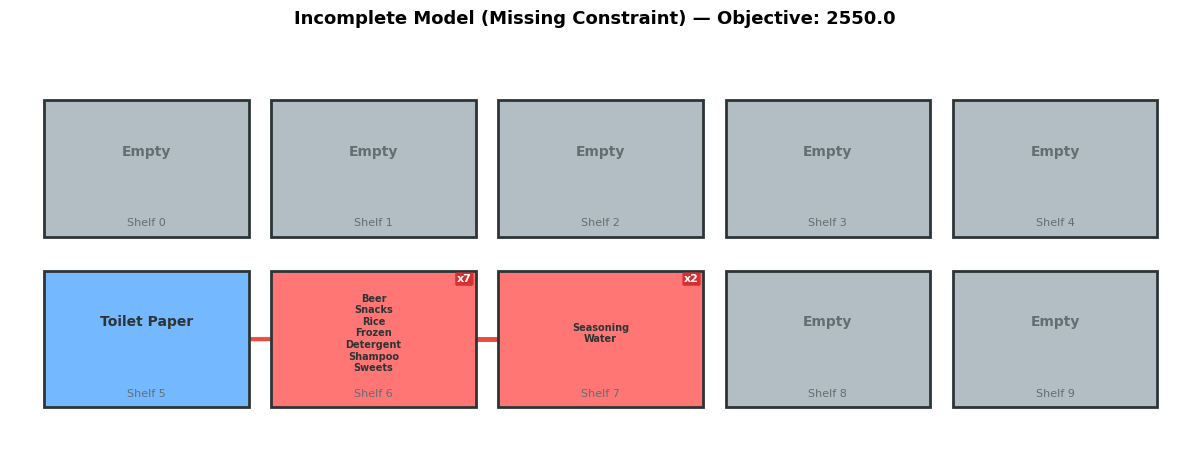

In [8]:
print("【不完全モデルの配置図】\n")
visualize_layout(
    assignment_incomplete,
    title="Incomplete Model (Missing Constraint)",
    objective=best_incomplete.objective,
)

---
## Step 5: 何が起きたのか？

### 原因: 棚容量制約の欠如

制約2「各棚には最大1つの商品」を省略したため、
ソルバーは **高頻度ペアを同じ棚に配置** しました。

- 同じ棚 → 距離 = 0 → 目的関数への寄与 = 0
- ソルバーにとっては「最適」だが、物理的に1つの棚に複数商品は置けない

### 教訓

> **目的関数値が低い ≠ 解が正しい**

数値だけ見ると「効率的！」に見えますが、
可視化すると「1つの棚に3商品?!」という異常が一目瞭然です。

`best_feasible_unrelaxed` は **定義済みの制約のみ** をチェックします。
省略した制約は検査されないため、「feasible」として返ってきます。

---
## Step 6: 制約を追加して正しいモデルで再求解

棚容量制約（各棚に最大1商品）を追加します。

In [9]:
@jm.Problem.define("warehouse_complete", sense=jm.ProblemSense.MINIMIZE)
def complete_model(problem: jm.DecoratedProblem):
    M = problem.Natural(description="商品数=棚数")
    f = problem.Float(shape=(M, M), description="同時注文頻度")
    d = problem.Float(shape=(M, M), description="棚間距離")
    x = problem.BinaryVar(shape=(M, M), description="配置 x[商品][棚]")

    # 目的関数: 頻度 × 距離 × 配置 の総和を最小化
    problem += jm.sum(
        f[p1, p2] * d[l1, l2] * x[p1, l1] * x[p2, l2]
        for p1 in M for p2 in M for l1 in M for l2 in M
    )

    # 制約1: 各商品は必ず1つの棚に配置
    problem += problem.Constraint(
        "one_product_per_shelf",
        [jm.sum(x[p, l] for l in M) == 1 for p in M],
        description="各商品は1棚に配置",
    )

    # 制約2: 各棚には必ず1つの商品を配置 ← 今回追加！
    problem += problem.Constraint(
        "one_shelf_per_product",
        [jm.sum(x[p, l] for p in M) == 1 for l in M],
        description="各棚に1商品を配置",
    )

print("【完全なモデル（制約1 + 制約2）】")
print(complete_model)

【完全なモデル（制約1 + 制約2）】
Problem(name="warehouse_complete", sense=MINIMIZE, objective=sum(M.flat_map(lambda (p1: natural): M.map(lambda (p2: natural): (p1, p2))).flat_map(lambda ((p1, p2): Tuple[natural, natural]): M.map(lambda (l1: natural): (p1, p2, l1))).flat_map(lambda ((p1, p2, l1): Tuple[natural, natural, natural]): M.map(lambda (l2: natural): (p1, p2, l1, l2))).map(lambda ((p1, p2, l1, l2): Tuple[natural, natural, natural, natural]): f[p1, p2] * d[l1, l2] * x[p1, l1] * x[p2, l2])), constraints={one_product_per_shelf: [Constraint(name="one_product_per_shelf", , lambda p: sum(M.map(lambda (l: natural): x[p, l])) == 1, domain=set(M), description="各商品は1棚に配置"),],one_shelf_per_product: [Constraint(name="one_shelf_per_product", , lambda l: sum(M.map(lambda (p: natural): x[p, l])) == 1, domain=set(M), description="各棚に1商品を配置"),],})


In [10]:
instance_complete = complete_model.eval(instance_data)

sample_set_complete = OMMXOpenJijSAAdapter.sample(
    instance_complete,
    num_reads=100,
    num_sweeps=2000,
    uniform_penalty_weight=5000.0,
)
best_complete = sample_set_complete.best_feasible_unrelaxed

---
## Step 7: 正しい結果の可視化

【完全モデルの配置図】



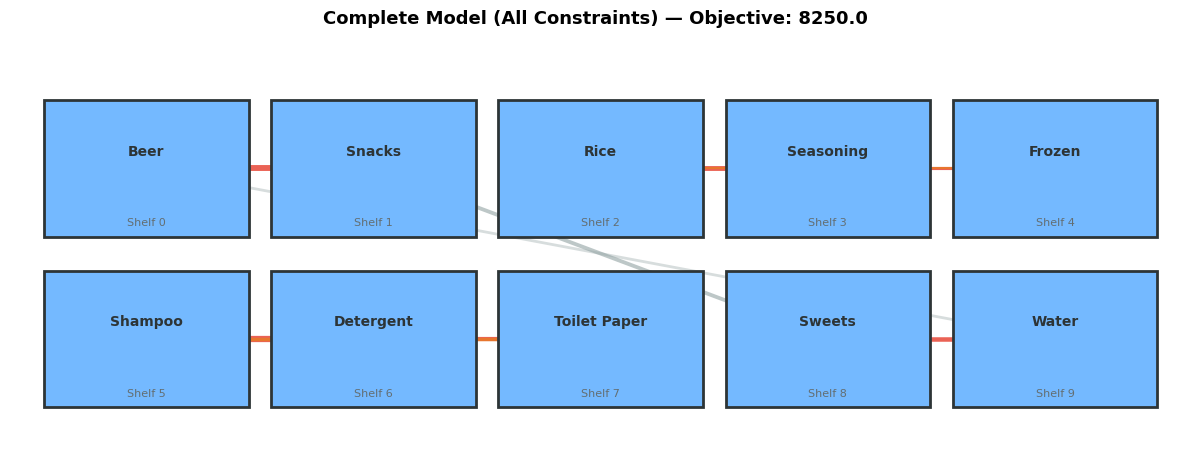

In [11]:
assignment_complete = extract_assignment(best_complete)

print("【完全モデルの配置図】\n")
visualize_layout(
    assignment_complete,
    title="Complete Model (All Constraints)",
    objective=best_complete.objective,
)

---
## Step 8: 比較 — 不完全 vs 完全モデル

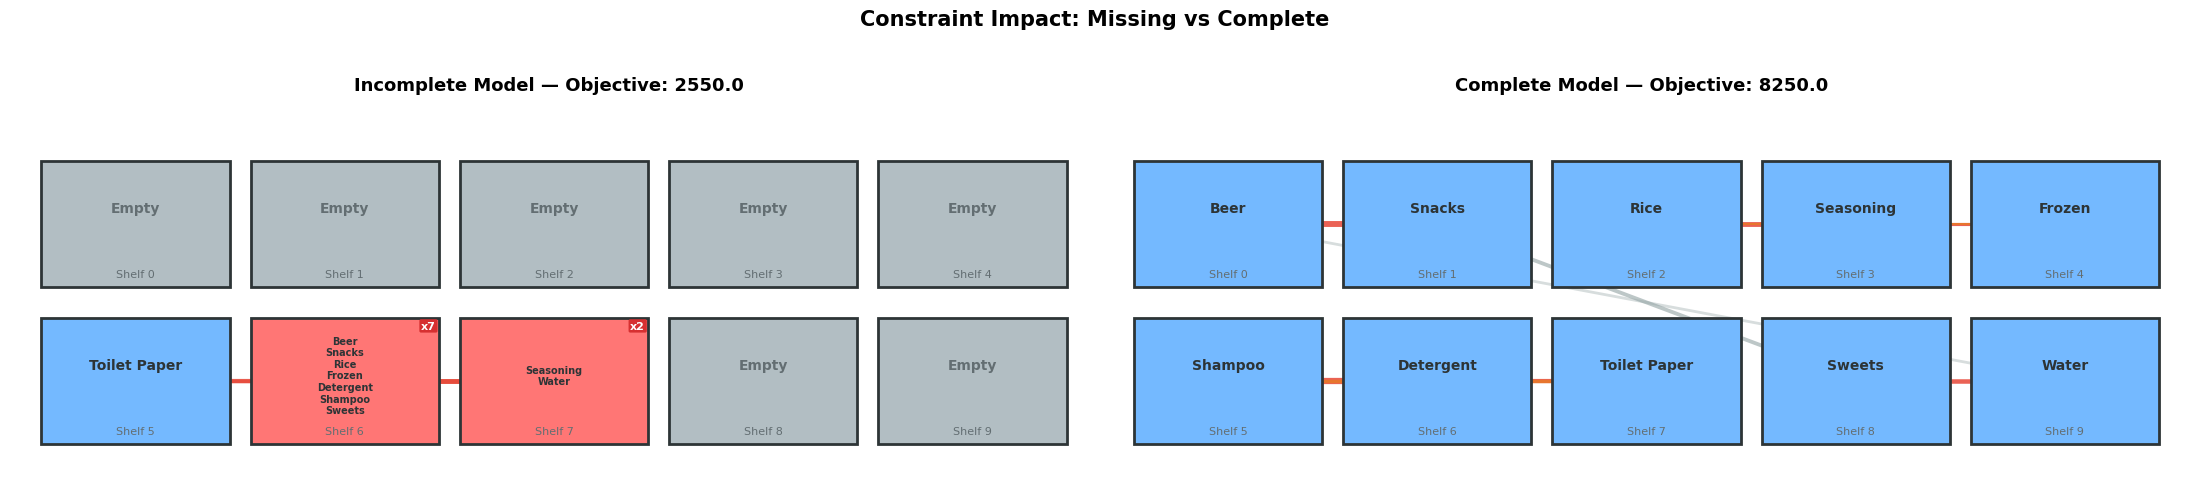

In [12]:
# 左右に並べた比較図
fig, axes = plt.subplots(1, 2, figsize=(22, 5))

draw_layout_on_ax(
    axes[0], assignment_incomplete,
    title="Incomplete Model",
    objective=best_incomplete.objective,
)
draw_layout_on_ax(
    axes[1], assignment_complete,
    title="Complete Model",
    objective=best_complete.objective,
)

fig.suptitle(
    "Constraint Impact: Missing vs Complete",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

In [13]:
# 高頻度ペアの距離比較テーブル
product_to_shelf_inc = {pi: li for pi, li in assignment_incomplete.items()}
product_to_shelf_com = {pi: li for pi, li in assignment_complete.items()}

print("【高頻度ペアの距離比較】\n")
print(f"  {'ペア':<24s}  {'頻度':>4s}  {'不完全モデル':>10s}  {'完全モデル':>8s}")
print(f"  {'-'*56}")

for p1, p2, freq in sorted(high_freq_pairs, key=lambda x: -x[2]):
    l1_inc = product_to_shelf_inc.get(p1, -1)
    l2_inc = product_to_shelf_inc.get(p2, -1)
    d_inc = dist_data[l1_inc, l2_inc] if l1_inc >= 0 and l2_inc >= 0 else float("inf")

    l1_com = product_to_shelf_com.get(p1, -1)
    l2_com = product_to_shelf_com.get(p2, -1)
    d_com = dist_data[l1_com, l2_com] if l1_com >= 0 and l2_com >= 0 else float("inf")

    pair_name = f"{product_names[p1]} - {product_names[p2]}"
    d_inc_str = f"{d_inc:.0f}m" if d_inc > 0 else "0m(!!)"
    d_com_str = f"{d_com:.0f}m"
    print(f"  {pair_name:<24s}  {freq:>4.0f}  {d_inc_str:>10s}  {d_com_str:>8s}")

print(f"\n  目的関数値:")
print(f"    不完全モデル: {best_incomplete.objective:.1f} ← 低いが解が不正")
print(f"    完全モデル:   {best_complete.objective:.1f} ← 正しい解")

【高頻度ペアの距離比較】

  ペア                          頻度      不完全モデル     完全モデル
  --------------------------------------------------------
  洗剤 - シャンプー                  90      0m(!!)        3m
  ビール - おつまみ                  85      0m(!!)        3m
  お米 - 調味料                    70          3m        3m
  お菓子 - 飲料水                   65          3m        3m
  洗剤 - トイレットペーパー              60          3m        3m
  おつまみ - お菓子                  55      0m(!!)        9m
  シャンプー - トイレットペーパー           50          3m        6m
  調味料 - 冷凍食品                  45          3m        3m
  ビール - 飲料水                   40          3m       15m
  お米 - 冷凍食品                   30      0m(!!)        6m

  目的関数値:
    不完全モデル: 2550.0 ← 低いが解が不正
    完全モデル:   8250.0 ← 正しい解


---
## まとめ

### 不完全モデル vs 完全モデル

| 項目 | 不完全モデル（制約1のみ） | 完全モデル（制約1+2） |
|------|--------------------------|----------------------|
| 制約 | 各商品→1棚 のみ | 各商品→1棚 + 各棚→1商品 |
| 目的関数値 | 非常に低い（見かけ上「最適」） | 適正な値 |
| 棚の状態 | 過密棚あり・空棚あり | 全棚に1商品ずつ |
| 実用性 | 物理的に不可能 | 実用可能 |

### 可視化チェックリスト

最適化の結果を受け取ったら、以下を必ず確認しましょう:

- [ ] 割り当てが1対1になっているか（過密・空きがないか）
- [ ] 高頻度ペアが近くに配置されているか
- [ ] 目的関数値だけでなく、解の「形」が妥当か
- [ ] 制約の漏れがないか

### JijModelingワークフロー（完全版）

```
① Problem定義（数式を書く）
    ↓
② Instance生成（具体的な数値を入れる）
    ↓
③ Solve（ソルバーで解く）
    ↓
④ 結果確認（最適解を取り出す）
    ↓
⑤ 可視化・検証 ← 今回のハンズオンで追加！
    ↓ 問題があれば①に戻る
```

> **可視化は「あれば便利」ではなく「なければ危険」です。**
> 数値を信じる前に、必ず解の形を目で確認しましょう。